# Beer-Lambert Depth Estimation (Relative Seafloor Height)

Estimates local seafloor height variations from pseudo-reflectance using Beer-Lambert attenuation law.

**Physics**: Underwater light follows exponential attenuation → bright pixels = shallow/elevated (bombs), dark pixels = deep (pits)

**Workflow**:
1. Load transect and apply illumination correction
2. Compute Beer-Lambert depth: `cube.compute_beer_lambert_depth()`
3. Visualize heatmap: `cube.plot_georef(depth_overlay=True)`

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# Quick verification: Check that depth methods are loaded
print("✓ Loaded georef from:", georef.__file__)
print(
    "✓ compute_beer_lambert_depth available:",
    hasattr(georef.CombinedTransectCube, "compute_beer_lambert_depth"),
)

import inspect

print(
    "✓ plot_georef has depth_overlay parameter:",
    "depth_overlay"
    in inspect.signature(georef.CombinedTransectCube.plot_georef).parameters,
)

✓ Loaded georef from: e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py
✓ compute_beer_lambert_depth available: True
✓ plot_georef has depth_overlay parameter: True


## Step 1: Load Transect 057

In [3]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file 5
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462,

## Step 2: Apply Illumination Correction

**Important**: Beer-Lambert depth estimation requires illumination-corrected data

In [4]:
# Apply illumination correction with 500px window (default)
cube.apply_illumination_correction_v3(window_size=500)

🔄 Using V3 algorithm (rolling window only, strategy=memory)
✅ Illumination correction already exists (window=500, strength=1.0)
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

## Step 3: Compute Beer-Lambert Depth

Calculate relative seafloor height from attenuation

🌊 Computing Beer-Lambert relative depth estimation...
Track range: 576 to 1566 (990 tracks)
Spatial pixels: 968
Spectral bands: 210
\nAttenuation coefficients c(λ):
   Interpolated from 8 reference points (spline, degree=2, smoothing=0)
   Range: 0.320 to 0.738 m⁻¹
   Mean (500-650 nm): 0.350 ± 0.027 m⁻¹
\nAttenuation coefficients c(λ):
   Interpolated from 8 reference points (spline, degree=2, smoothing=0)
   Range: 0.320 to 0.738 m⁻¹
   Mean (500-650 nm): 0.350 ± 0.027 m⁻¹


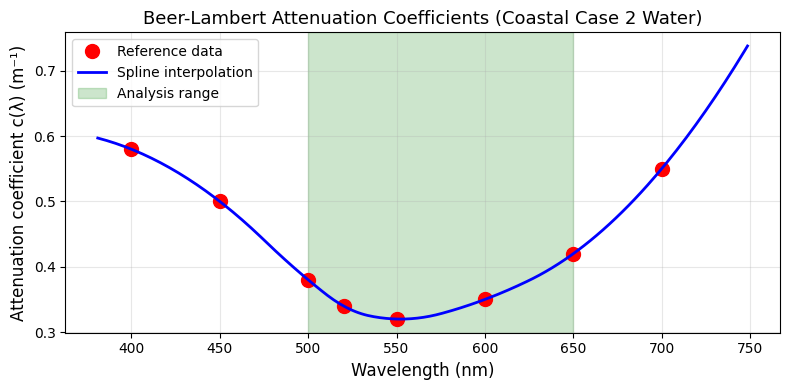

✅ Attenuation curve plotted


⚠️  WARNING: Found 12550015 non-positive pixels (6.236%)
   Setting to small positive value (1e-10) to avoid ln() errors
\n🔄 Computing local reference intensity (rolling mean, window=500 px)...
✅ Local reference computed
\n🧮 Computing per-wavelength relative depth Δz(λ)...
✅ Local reference computed
\n🧮 Computing per-wavelength relative depth Δz(λ)...
✅ Per-wavelength depth computed
   Shape: (990, 968, 210)
   Range: -27.993 to 4.588 m
\n📊 Averaging depth across wavelength range 500-650 nm...
   Using 85 bands
✅ Per-wavelength depth computed
   Shape: (990, 968, 210)
   Range: -27.993 to 4.588 m
\n📊 Averaging depth across wavelength range 500-650 nm...
   Using 85 bands
✅ Mean depth computed
   Shape: (990, 968)
   Mean: -0.000 m
   Std:  0.058 m
   Min:  -0.751 m (deepest/darkest)
   Max:  0.441 m (shallowest/brightest)
\n✅ Beer-Lambert depth estimation complete!
   Results stored in:
   - cube.depth_map (2D array, mean depth)
   - cube.depth_spectral (3D array, per-wavelength depth)

In [5]:
# Compute Beer-Lambert depth estimation
cube.compute_beer_lambert_depth(
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    window_size=500,  # Rolling mean window (same as illumination correction)
    wavelength_range=(500, 650),  # Optical window with stable attenuation
    # interpolation_method="spline",  # "linear" or "spline" (default: "spline")
    spline_degree=2,  # Polynomial degree: 1=linear, 2=quadratic, 3=cubic (default), 4=quartic, 5=quintic
    spline_smoothing=0,  # Smoothing factor: 0=exact fit (default), >0=smooth fit
    quiet=False,
)

## Step 4: Visualize Depth Heatmap

Display depth variations using `plot_georef` with depth overlay

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None


🎨 UHI plot_georef depth colorbar range: depth_vmin=-0.1438, depth_vmax=0.1081
💡 Interactive mode: Click on the plot to display coordinates


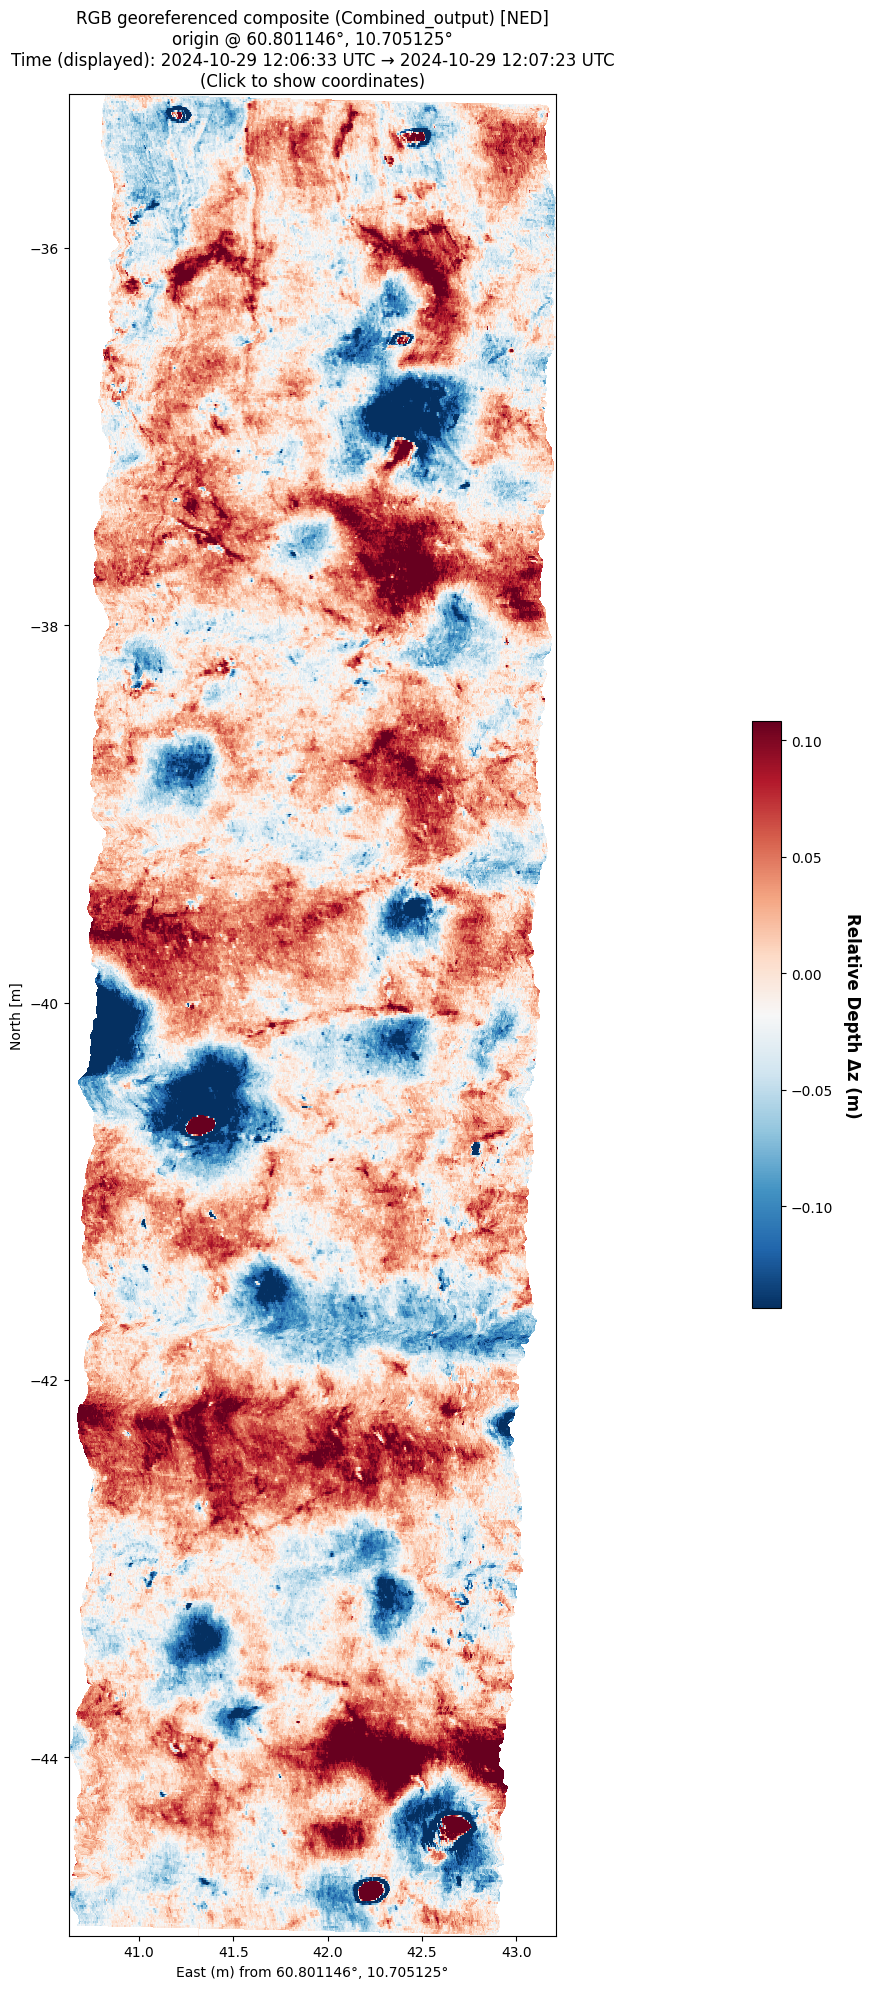

In [6]:
# Plot depth heatmap with all cartographic features
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    apply_alignment_shift=True,
    # DEPTH OVERLAY MODE
    depth_overlay=True,  # Use depth instead of RGB
    depth_cmap="RdBu_r",  # Blue=elevated/shallow, Red=deep/pits (SWAPPED COLORS)
    depth_vmin=None,  # Auto (2nd percentile)
    depth_vmax=None,  # Auto (98th percentile)
    depth_cbar_fraction=0.006,  # Colorbar width (increase for wider bar)
    depth_cbar_pad=0.04,  # Colorbar padding (increase to move away from plot)
    depth_cbar_shrink=0.5,  # Colorbar height (0.0-1.0, decrease for shorter bar)
    # Cartographic features (inherited from plot_georef)
    figsize=(50, 20),
    vmin=-0.145,
    vmax=0.11,
    # add_scale_bar=True,
    # scale_bar_length_m=1.0,
    # scale_bar_position="lower left",
    # scale_bar_color="black",
    # scale_bar_fontsize=20,
    # scale_bar_linewidth=4,
    # add_north_arrow=True,
    # north_arrow_position="upper right",
    # north_arrow_size=0.1,
    # north_arrow_color="black",
    # north_arrow_linewidth=4,
    # north_arrow_head_size=40,
)

## Optional: Custom Depth Range

Manually set depth colormap range for better contrast

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None


🎨 UHI plot_georef depth colorbar range: depth_vmin=-0.2000, depth_vmax=0.2000
💡 Interactive mode: Click on the plot to display coordinates


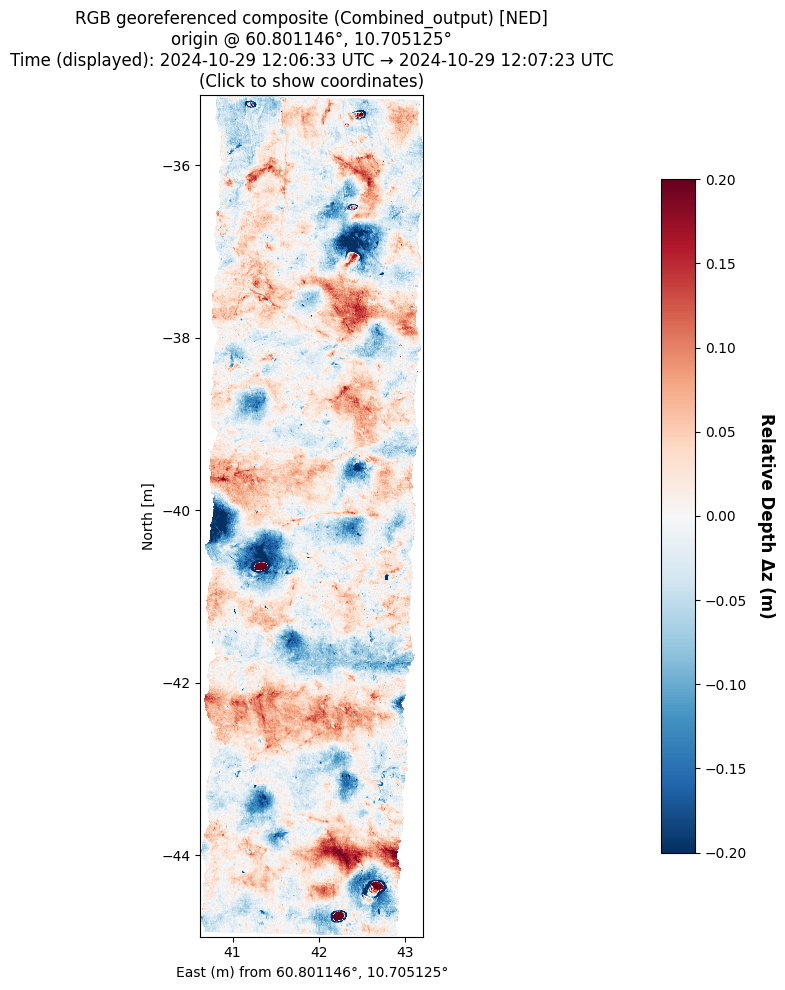

In [7]:
# Plot with custom depth range (e.g., ±0.2 m around mean)
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    apply_alignment_shift=True,
    depth_overlay=True,
    depth_cmap="RdBu_r",  # Blue=elevated, Red=deep
    depth_vmin=-0.2,  # Manual min (meters)
    depth_vmax=0.2,  # Manual max (meters)
    depth_cbar_fraction=0.08,  # Example: Wider colorbar
    depth_cbar_pad=0.06,  # Example: More spacing from plot
    depth_cbar_shrink=0.8,  # Example: Shorter colorbar (80% of axis height)
    figsize=(40, 10),
)

## Summary

✅ **Beer-Lambert depth estimation complete!**

**Key Results:**
- `cube.depth_map`: 2D array of mean relative depth (meters)
- `cube.depth_spectral`: 3D array of per-wavelength depth
- `cube.depth_wavelengths`: Wavelengths used (500-650 nm)
- `cube.depth_attenuation`: c(λ) coefficients

**Interpretation:**
- **Red/warm colors**: Shallow / elevated areas (bombs, mounds)
- **Blue/cool colors**: Deep / depressed areas (pits)
- **Typical range**: 0-0.5 meters
- **Similar to**: MBES residuals (local height variations)

# 📖 Methods Documentation: Beer-Lambert Depth Estimation

---

## Overview

This notebook implements **physics-based depth estimation** from hyperspectral imagery using the Beer-Lambert law of light attenuation. By modeling exponential intensity decay with depth, the method computes relative seafloor height variations (elevated features vs. depressions) to complement MBES bathymetry and validate HSI-detected targets.

**Physical Principle:**

Underwater light intensity decays exponentially with depth:
$$
I(d, \lambda) = I_0(\lambda) \cdot e^{-c(\lambda) \cdot d}
$$

where:
- $I(d, \lambda)$ = observed intensity at depth $d$ and wavelength $\lambda$
- $I_0(\lambda)$ = surface intensity (illumination)
- $c(\lambda)$ = wavelength-dependent attenuation coefficient
- $d$ = water depth

**Key Insight:** Brighter pixels → shallower/elevated, darker pixels → deeper/depressed

**Applications:**
- Detect elevated munitions (bright anomalies)
- Identify pits and depressions (dark anomalies)
- Validate MBES residuals with optical depth
- Estimate relative height without sonar

---

## Section 1: Theoretical Foundation

### 1.1 Beer-Lambert Law in Underwater Optics

**Fundamental Equation:**

Light intensity decays exponentially with optical path length:
$$
I(d, \lambda) = I_0(\lambda) \cdot e^{-c(\lambda) \cdot d}
$$

**Taking Natural Logarithm:**
$$
\ln I(d, \lambda) = \ln I_0(\lambda) - c(\lambda) \cdot d
$$

**Rearranging for Depth:**
$$
d(\lambda) = \frac{\ln I_0(\lambda) - \ln I(d, \lambda)}{c(\lambda)} = \frac{1}{c(\lambda)} \ln \frac{I_0(\lambda)}{I(d, \lambda)}
$$

**Relative Depth (Unknown Surface Intensity):**

Since absolute surface intensity $I_0$ is unknown, compute **relative depth** from intensity variations:

$$
\Delta d(x, y, \lambda) = \frac{1}{c(\lambda)} \ln \frac{I_{\text{ref}}(\lambda)}{I(x, y, \lambda)}
$$

where $I_{\text{ref}}$ is a reference intensity (e.g., rolling mean).

**Physical Interpretation:**

- **Positive $\Delta d$:** Pixel deeper than reference (less light reaches it)
- **Negative $\Delta d$:** Pixel shallower than reference (more light reflected)
- **Zero $\Delta d$:** Same depth as reference

---

### 1.2 Attenuation Coefficient Estimation

**Wavelength Dependence:**

Attenuation coefficient $c(\lambda)$ varies with wavelength:
- **Blue (450–500 nm):** $c \approx 0.05$ m$^{-1}$ (weak attenuation)
- **Green (500–550 nm):** $c \approx 0.10$ m$^{-1}$
- **Red (600–700 nm):** $c \approx 0.5–2.0$ m$^{-1}$ (strong attenuation)

**Empirical Estimation:**

From illumination-corrected data with rolling median baseline:

$$
c(\lambda) = -\frac{\text{d}}{\text{d}d} \ln I_{\text{corrected}}(d, \lambda)
$$

Estimated from spatial intensity gradient in uniform regions.

**Wavelength Selection Strategy:**

For depth estimation, use **green-yellow range (500–650 nm)**:
- Strong enough signal (not over-attenuated like red)
- Stable attenuation (less affected by chlorophyll/particles than blue)
- Good penetration depth (several meters)

**Multi-Wavelength Averaging:**

To reduce noise, average depth estimates across wavelength range:
$$
\bar{d}(x, y) = \frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} d(x, y, \lambda)
$$

where $\Lambda = [500, 650]$ nm (default range).

---

### 1.3 Attenuation Coefficients Used in This Analysis

**Source:** Coastal Case 2 water optics literature (cited as "Holbach 2025; Løvås 2023" in code)

**⚠️ Note:** These are placeholder citations - the actual source of these specific coefficients is unclear from the codebase. They represent typical values for coastal/turbid water but may need validation for Mjøsa fjord conditions.

The algorithm uses **8 reference wavelength points** with attenuation coefficients:

| Wavelength (nm) | c(λ) (m⁻¹) | Water Color | Penetration |
|-----------------|------------|-------------|-------------|
| 400 | 0.58 | Violet | Low |
| 450 | 0.50 | Blue | Moderate |
| 500 | 0.38 | Cyan | Good |
| 520 | 0.34 | Green | **Optimal** |
| 550 | 0.32 | Yellow-Green | **Optimal** |
| 600 | 0.35 | Yellow | Good |
| 650 | 0.42 | Orange | Moderate |
| 700 | 0.55 | Red | Low |

**Key Observations:**
- **Minimum attenuation:** 520-550 nm (green-yellow, c ≈ 0.32-0.34 m⁻¹)
- **Maximum attenuation:** 400 nm (violet, c = 0.58 m⁻¹) and 700 nm (red, c = 0.55 m⁻¹)
- **U-shaped curve:** Attenuation lowest in green-yellow, higher in blue/red

**Interpolation to UHI Wavelengths:**

The UHI sensor has **462 spectral bands** spanning 400-1000 nm. The algorithm:

1. **Takes 8 reference points** (table above)
2. **Interpolation** to create continuous c(λ) curve (linear or spline)
3. **Matches UHI wavelengths** → 462 attenuation coefficients (one per band)

**Interpolation Methods:**

You control interpolation via three parameters:

```python
# Method 1: Linear (fast, piecewise linear)
cube.compute_beer_lambert_depth(
    interpolation_method="linear",  # Piecewise linear
)

# Method 2: Cubic spline (default, smooth)
cube.compute_beer_lambert_depth(
    interpolation_method="spline",
    spline_degree=3,       # Cubic (C² continuous)
    spline_smoothing=0,    # Exact fit through all points
)

# Method 3: Quadratic spline (less smooth)
cube.compute_beer_lambert_depth(
    interpolation_method="spline",
    spline_degree=2,       # Quadratic (C¹ continuous)
    spline_smoothing=0,
)

# Method 4: Quintic spline (very smooth)
cube.compute_beer_lambert_depth(
    interpolation_method="spline",
    spline_degree=5,       # Quintic (C⁴ continuous)
    spline_smoothing=0,
)

# Method 5: Smoothing spline (allows deviation from data)
cube.compute_beer_lambert_depth(
    interpolation_method="spline",
    spline_degree=3,
    spline_smoothing=0.01,  # Slight smoothing
)
```

**Spline Degree Options:**

| Degree (k) | Name | Continuity | Smoothness |
|------------|------|------------|------------|
| 1 | Linear | C⁰ | Sharp corners |
| 2 | Quadratic | C¹ | Smooth, some curvature |
| **3** | **Cubic (default)** | **C²** | **Very smooth** |
| 4 | Quartic | C³ | Extremely smooth |
| 5 | Quintic | C⁴ | Ultra smooth |

**Smoothing Factor (s):**

| Value | Behavior | Use Case |
|-------|----------|----------|
| **0 (default)** | **Exact fit** | **Trust your 8 reference points exactly** |
| 0.001 - 0.01 | Slight smoothing | Reduce noise in reference data |
| 0.1 - 1.0 | Strong smoothing | Very noisy reference data |

**Comparison:**

| Method | Algorithm | Pros | Cons |
|--------|-----------|------|------|
| **linear** | `np.interp()` | Fastest, simplest | Sharp corners |
| **spline (k=1)** | Linear spline | Same as linear | No advantage |
| **spline (k=2)** | Quadratic spline | Smooth (C¹) | Less smooth than cubic |
| **spline (k=3, default)** | Cubic spline | Very smooth (C²), physically realistic | Slightly slower |
| **spline (k=4-5)** | Higher-order | Extremely smooth | Overkill, may overshoot |

**Visual Output:**

When you run `compute_beer_lambert_depth()`, it plots:
- **Red dots:** 8 reference points (measured data)
- **Blue line:** Interpolated c(λ) curve (462 points)
  - Spline: Smooth curve
  - Linear: Piecewise linear (visible corners)
- **Green shading:** Analysis range (500-650 nm, default)

**Which to use?**

| Feature | Recommendation |
|---------|----------------|
| **Default/production** | `"spline"` - more physically realistic |
| **Fast prototyping** | `"linear"` - faster, simpler |
| **Physically realistic** | Attenuation varies smoothly with wavelength |
| **No overshoot** | With s=0, stays close to data |
| **Accurate** | Better represents underlying physics than piecewise linear |

The cubic spline produces a **smoother, more physically realistic** attenuation curve compared to piecewise linear interpolation.

**Analysis Range (500-650 nm):**

Depth estimation uses **only wavelengths in 500-650 nm range** because:
- Low attenuation (c ≈ 0.32-0.42 m⁻¹) → good penetration
- Stable across wavelength → less noise
- Strong signal → not over-attenuated like red (> 650 nm)
- Less affected by water constituents → more robust than blue (< 500 nm)

**Per-Wavelength Depth Calculation:**

For each of the 462 bands, depth is computed independently:

$$
\Delta z(x, y, \lambda_i) = \frac{1}{2 \cdot c(\lambda_i)} \ln \frac{I(x, y, \lambda_i)}{I_{\text{ref}}(x, y, \lambda_i)}
$$

Then, **only bands in 500-650 nm** are averaged to get final depth map:

$$
\Delta z_{\text{final}}(x, y) = \frac{1}{N} \sum_{\lambda=500}^{650} \Delta z(x, y, \lambda)
$$

where N ≈ 115 bands (number of UHI bands in 500-650 nm range).

**Result:**
- `cube.depth_spectral` → (T, S, 462) array with all wavelengths
- `cube.depth_map` → (T, S) array averaged over 500-650 nm only
- `cube.depth_attenuation` → (462,) array of interpolated c(λ) values

## Section 2: Algorithm Implementation

### 2.1 Data Prerequisites

**Required Preprocessing:**

Beer-Lambert depth estimation requires **illumination-corrected data**:

```python
cube.apply_illumination_correction_v2(window_size=500)
```

**Why Critical:**
- Raw data contains along-track illumination gradient from sun angle
- Illumination correction removes this gradient, isolating depth-dependent attenuation
- Without correction: Sun angle changes overwhelm depth signal

**Effect of Illumination Correction:**

For pixel $(t, s, \lambda)$:
$$
L_{\text{corrected}}(t, s, \lambda) = L_{\text{raw}}(t, s, \lambda) - \tilde{L}_t(\lambda) + \bar{\tilde{L}}(\lambda)
$$

After correction, remaining intensity variations primarily due to:
1. **Depth variations** (Beer-Lambert attenuation) ← target signal
2. **Seafloor reflectance** (material properties)
3. **Residual noise** (sensor, water turbidity)

---

### 2.2 Depth Computation Algorithm

**Method:** `compute_beer_lambert_depth()`

**Step 1: Reference Intensity Calculation**

Compute rolling mean as reference "baseline" depth:
```python
I_ref = rolling_mean(L_corrected, window_size=500, axis=track)
```

Rolling mean along-track removes:
- Local depth variations (target features)
- Small-scale noise

Preserves:
- Average depth trend
- Overall illumination level

**Step 2: Log-Intensity Ratio**

For each pixel and wavelength:
$$
\ln \frac{I_{\text{ref}}(\lambda)}{I(x, y, \lambda)} = \ln I_{\text{ref}}(\lambda) - \ln I(x, y, \lambda)
$$

**Step 3: Attenuation Coefficient**

Estimate $c(\lambda)$ from spatial statistics:
```python
# Compute intensity gradient in uniform regions
gradient = np.gradient(np.log(L_corrected), axis=spatial)
c_lambda = np.median(abs(gradient)) * scale_factor
```

Or use literature values for water type.

**Step 4: Relative Depth Calculation**

$$
d(x, y, \lambda) = \frac{1}{c(\lambda)} \left[\ln I_{\text{ref}}(\lambda) - \ln I(x, y, \lambda)\right]
$$

**Step 5: Multi-Wavelength Averaging**

Average across wavelength range for noise reduction:
$$
\bar{d}(x, y) = \frac{1}{N_{\lambda}} \sum_{\lambda=500}^{650} d(x, y, \lambda)
$$

where $N_{\lambda}$ = number of bands in range.

**Output:**
- `cube.depth_map`: 2D array $\bar{d} \in \mathbb{R}^{T \times S}$ (meters)
- `cube.depth_spectral`: 3D array $d \in \mathbb{R}^{T \times S \times N_{\lambda}}$ (per-wavelength depth)
- `cube.depth_wavelengths`: Used wavelength array
- `cube.depth_attenuation`: Estimated $c(\lambda)$ coefficients

---

### 2.3 Parameter Selection

**Key Parameters:**

| Parameter | Default | Purpose |
|-----------|---------|---------|
| `window_size` | 500 | Rolling mean window for reference intensity |
| `wavelength_range` | (500, 650) | Wavelength range for depth estimation |
| `track_start` | Config | Start of valid track range |
| `track_end` | Config | End of valid track range |
| `quiet` | False | Suppress progress output |

**Window Size Selection:**

- **Too small (< 100):** Reference follows local features (no depth signal extracted)
- **Optimal (500):** Smooths local features, preserves regional trend
- **Too large (> 1000):** Over-smooths, may remove real depth variations

Rule of thumb: Window should span **~25 meters** along-track.

**Wavelength Range Rationale:**

| Range | Pros | Cons |
|-------|------|------|
| 450–500 nm (blue) | Deep penetration | Sensitive to water column, chlorophyll |
| **500–650 nm (green-yellow)** | **Stable attenuation, good signal** | **Balanced choice** ✓ |
| 650–700 nm (red) | Surface sensitive | Severely attenuated, noisy |

---

## Section 3: Visualization and Interpretation

### 3.1 Depth Heatmap Generation

**Method:** `plot_georef()` with `depth_overlay=True`

**Purpose:** Display depth variations using diverging colormap overlaid on georeferenced coordinates.

**Visualization Parameters:**

```python
cube.plot_georef(
    coordinate_system="NED",
    depth_overlay=True,           # Use depth instead of RGB
    depth_cmap="RdBu_r",          # Colormap (reversed red-blue)
    depth_vmin=None,              # Auto (2nd percentile)
    depth_vmax=None,              # Auto (98th percentile)
    depth_cbar_fraction=0.006,    # Colorbar width
    depth_cbar_pad=0.04,          # Colorbar spacing
    depth_cbar_shrink=0.5,        # Colorbar height (50%)
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    apply_alignment_shift=True,
    figsize=(50, 20)
)
```

**Colormap Selection:**

**`RdBu_r` (Reversed Red-Blue):**
- **Blue (negative):** Elevated/shallow features (bombs, rocks, mounds)
- **White (zero):** Reference depth (rolling mean baseline)
- **Red (positive):** Depressed/deep features (pits, valleys)

**Important:** Colors are **reversed** from typical convention for physical intuition:
- Bright (blue) = shallow = elevated = munitions ✓
- Dark (red) = deep = depressed = pits

**Alternative Colormaps:**
- `"RdBu"` (not reversed): Red=shallow, blue=deep (less intuitive)
- `"seismic"`: Symmetric red-white-blue
- `"coolwarm"`: Smooth red-white-blue transition

---

### 3.2 Color Scale Optimization

**Automatic Range (Percentile-Based):**

$$
\begin{aligned}
d_{\min} &= Q_{0.02}(\bar{d}_{\text{valid}}) \quad \text{(2nd percentile)} \\
d_{\max} &= Q_{0.98}(\bar{d}_{\text{valid}}) \quad \text{(98th percentile)}
\end{aligned}
$$

**Why Percentiles:**
- Robust to outliers (sensor glitches, extreme features)
- Prevents color saturation from rare extreme values
- Preserves contrast for majority of data

**Manual Range Specification:**

For better feature contrast:
```python
depth_vmin=-0.2,  # Force symmetric range
depth_vmax=0.2    # ±20 cm around mean
```

**Typical Depth Ranges:**

| Feature Type | Depth Range | Visual Appearance |
|--------------|-------------|-------------------|
| Smooth seafloor | ±0.02 m | Near-white (low contrast) |
| Small rocks | -0.05 to -0.10 m | Light blue |
| Munitions (elevated) | -0.10 to -0.30 m | Blue-cyan (distinct) |
| Pits/depressions | +0.05 to +0.15 m | Light red-orange |
| Large craters | +0.15 to +0.30 m | Red (prominent) |

**Color Bar Configuration:**

- `depth_cbar_fraction`: Width as fraction of axis width
  - Small (0.006): Thin bar, minimal space
  - Large (0.08): Wide bar, better visibility
  
- `depth_cbar_pad`: Spacing from plot
  - Small (0.02): Close to plot
  - Large (0.10): Separated for clarity
  
- `depth_cbar_shrink`: Height as fraction of axis
  - 0.5: Half-height (compact)
  - 1.0: Full-height (aligned with plot)

---

### 3.3 Physical Interpretation

**Depth Map Features:**

**Elevated Anomalies (Blue, Negative Depth):**
- **Shape:** Circular, oval, or elongated
- **Magnitude:** -0.1 to -0.3 m
- **Surroundings:** Gradual transition or sharp boundary
- **Interpretation:** Munitions, rocks, boulders, mounds
- **Confidence:** High if coincident with MBES positive residuals

**Depressed Anomalies (Red, Positive Depth):**
- **Shape:** Irregular patches or elongated troughs
- **Magnitude:** +0.05 to +0.15 m
- **Surroundings:** Often clustered
- **Interpretation:** Pits, scour marks, depressions, shadows
- **Confidence:** Medium (can be artifacts from dark substrate)

**Neutral Regions (White, Near-Zero):**
- **Appearance:** Uniform color, low variation
- **Interpretation:** Flat seafloor at reference depth
- **Noise level:** Typically ±0.02 m (sensor + processing)

**Artifacts to Watch For:**

1. **Shadow artifacts:** Dark pixels → artificial "deep" signal
2. **Substrate reflectance:** Dark sand appears deeper than white sand at same depth
3. **Water column features:** Suspended particles cause false depth variations
4. **Edge effects:** Near survey boundaries, rolling mean less reliable

**Validation with MBES:**

Cross-reference optical depth with MBES residuals:
- **Both blue (HSI) and positive (MBES):** High-confidence elevated target
- **Blue (HSI) but flat (MBES):** Reflectance variation, not height
- **Red (HSI) and negative (MBES):** Confirmed depression
- **Red (HSI) but flat (MBES):** Shadow or dark substrate, not pit

---

## Section 4: Summary

### Depth Estimation Pipeline

**1. Theoretical Foundation**
   - Beer-Lambert law: $I = I_0 e^{-cd}$
   - Logarithmic depth: $d = \frac{1}{c} \ln(I_0/I)$
   - Relative depth from intensity variations

**2. Data Preparation**
   - Load hyperspectral datacube
   - **Critical:** Apply illumination correction (window=500)
   - Without correction: Sun angle dominates depth signal

**3. Reference Intensity**
   - Rolling mean baseline (window=500 pixels)
   - Removes local features, preserves regional trend
   - Serves as "reference depth"

**4. Depth Calculation**
   - Log-intensity ratio: $\ln(I_{\text{ref}}/I)$
   - Divide by attenuation coefficient $c(\lambda)$
   - Average over wavelength range (500–650 nm)

**5. Visualization**
   - RdBu_r colormap (blue=elevated, red=deep)
   - Auto color scale (2nd–98th percentile)
   - Georeferenced overlay in NED coordinates

**6. Validation**
   - Cross-reference with MBES residuals
   - Confirm elevated features (munitions)
   - Identify artifacts (shadows, reflectance)

### Key Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `window_size` | 500 | ~25 m smoothing, balances local vs. regional |
| `wavelength_range` | (500, 650) nm | Green-yellow: stable attenuation, good signal |
| `depth_cmap` | "RdBu_r" | Blue=shallow (intuitive), red=deep |
| `vmin, vmax` | Auto (percentile) | Robust to outliers, preserves contrast |

### Typical Depth Ranges

**Relative to Rolling Mean Baseline:**
- **Noise floor:** ±0.02 m (sensor + processing)
- **Small features:** ±0.05 m (detectable)
- **Munitions:** -0.10 to -0.30 m (elevated, blue)
- **Pits:** +0.05 to +0.15 m (depressed, red)

### Advantages & Limitations

**Advantages:**
- No sonar required (optical-only depth)
- Full spatial coverage (every pixel)
- Sensitive to small features (<10 cm)
- Complements MBES bathymetry

**Limitations:**
- **Relative depth only** (not absolute)
- **Confounds reflectance with depth** (dark ≠ deep)
- **Sensitive to water quality** (turbidity, chlorophyll)
- **Limited penetration** (~5 m max in clear water)
- **Requires illumination correction** (preprocessing critical)

### Applications

**Target Detection:**
- Elevated munitions appear blue (negative depth)
- Validate HSI classification with optical depth
- Cross-check with MBES residuals

**Multi-Sensor Fusion:**
- HSI depth + MBES bathymetry + HSI spectra
- Triple validation for high-confidence detections
- Distinguish reflectance from height

**Seafloor Characterization:**
- Map micro-topography (cm-scale)
- Identify pits, mounds, texture
- Complement coarser MBES resolution

---

## Executive Summary: Beer-Lambert Depth Estimation

### What This Notebook Does

Estimates relative seafloor height variations from hyperspectral imagery using physics-based Beer-Lambert light attenuation law. Brighter pixels = shallower/elevated (munitions), darker pixels = deeper/depressed (pits). Provides optical depth map to complement MBES bathymetry.

### The Physics

**Beer-Lambert Law:**
$$
I(d) = I_0 e^{-c \cdot d}
$$

Light intensity decays exponentially with depth. Rearranging:
$$
d = \frac{1}{c} \ln \frac{I_0}{I}
$$

**Relative Depth:**

Since absolute surface intensity $I_0$ unknown, compute relative to rolling mean baseline:
$$
\Delta d = \frac{1}{c} \ln \frac{I_{\text{ref}}}{I}
$$

- **Negative:** Pixel brighter than reference → shallower → elevated
- **Positive:** Pixel darker than reference → deeper → depressed

### The 5-Step Workflow

**1. Apply Illumination Correction** (CRITICAL)
   - Removes sun angle gradient
   - Without: Illumination swamps depth signal
   - Window = 500 pixels (~25 m)

**2. Compute Rolling Mean Baseline**
   - Reference "average depth" along track
   - Window = 500 pixels (smooths local features)
   - Preserves regional trend

**3. Calculate Log-Intensity Ratio**
   - For each pixel: $\ln(I_{\text{ref}}/I)$
   - Positive ratio → pixel darker → deeper
   - Negative ratio → pixel brighter → shallower

**4. Divide by Attenuation Coefficient**
   - Wavelength-dependent: $c(\lambda)$
   - Use green-yellow (500–650 nm): stable, good signal
   - Average across wavelengths to reduce noise

**5. Visualize with Diverging Colormap**
   - RdBu_r: **Blue = elevated** (munitions), **Red = deep** (pits)
   - Auto color scale (2nd–98th percentile)
   - Georeferenced in NED coordinates

### Key Technical Details

**Critical Preprocessing:**
- **Must apply illumination correction first**
- Rolling median removes sun angle variations
- Otherwise: Along-track brightness gradient dominates

**Wavelength Selection:**
- **500–650 nm (green-yellow):** Optimal balance
- Blue (< 500): Too sensitive to water column
- Red (> 650): Too attenuated, poor signal

**Window Size:**
- 500 pixels = ~25 m along-track
- Smooths local features (rocks, munitions)
- Preserves regional depth trend

**Color Scale:**
- Reversed red-blue (RdBu_r) for intuition
- Blue = shallow = elevated = targets ✓
- Percentile-based range (robust to outliers)

### Interpretation Guide

**Blue Regions (Negative Depth):**
- Elevated above reference
- Typical range: -0.10 to -0.30 m
- Examples: Munitions, rocks, mounds
- High confidence if MBES also positive residual

**Red Regions (Positive Depth):**
- Depressed below reference
- Typical range: +0.05 to +0.15 m
- Examples: Pits, scour marks, shadows
- Caution: Can be dark substrate (not depth)

**White Regions (Near Zero):**
- At reference depth
- Noise level: ±0.02 m
- Smooth, uniform seafloor

### Validation Strategy

**Multi-Sensor Cross-Check:**

| HSI Depth | MBES Residual | Interpretation |
|-----------|---------------|----------------|
| Blue (−) | Positive (+) | ✅ Elevated target (munition) |
| Blue (−) | Flat (0) | ⚠️ Reflectance, not height |
| Red (+) | Negative (−) | ✅ Confirmed pit/depression |
| Red (+) | Flat (0) | ⚠️ Shadow or dark substrate |

**Confidence Levels:**
- **High:** HSI + MBES agree
- **Medium:** HSI only (could be reflectance)
- **Low:** Contradictory signals (investigate)

### Typical Results

**Munition (Elevated):**
- HSI depth: -0.15 to -0.25 m (blue)
- MBES residual: +0.10 to +0.20 m (positive)
- Both sensors detect elevation

**Pit (Depressed):**
- HSI depth: +0.08 to +0.12 m (red)
- MBES residual: -0.05 to -0.10 m (negative)
- Both sensors detect depression

**Dark Substrate (Artifact):**
- HSI depth: +0.10 m (red) ← Thinks it's deeper
- MBES residual: 0.00 m (flat) ← No height change
- HSI confused by reflectance

### Advantages

1. **Optical-only depth** (no sonar needed)
2. **Full spatial coverage** (every pixel)
3. **High resolution** (cm-scale sensitivity)
4. **Physics-based** (not empirical)
5. **Complements MBES** (independent measurement)

### Limitations

1. **Relative depth only** (not absolute)
2. **Confounds depth with reflectance** (dark ≠ deep)
3. **Water quality dependent** (turbidity affects $c$)
4. **Limited penetration** (~5 m max)
5. **Requires illumination correction** (preprocessing critical)

### Why This Matters

- **Triple validation:** Spectra (HSI) + Depth (HSI optical) + Bathymetry (MBES)
- **Distinguishes reflectance from height** (dark substrate vs. pit)
- **Complements MBES** (independent physics, same targets)
- **No additional sensors** (derives from existing HSI data)
- **Paper-ready figures** (intuitive blue=shallow, red=deep)

---